# **Task 1 Bar Chart visualising the Population by Gender and Age groups**

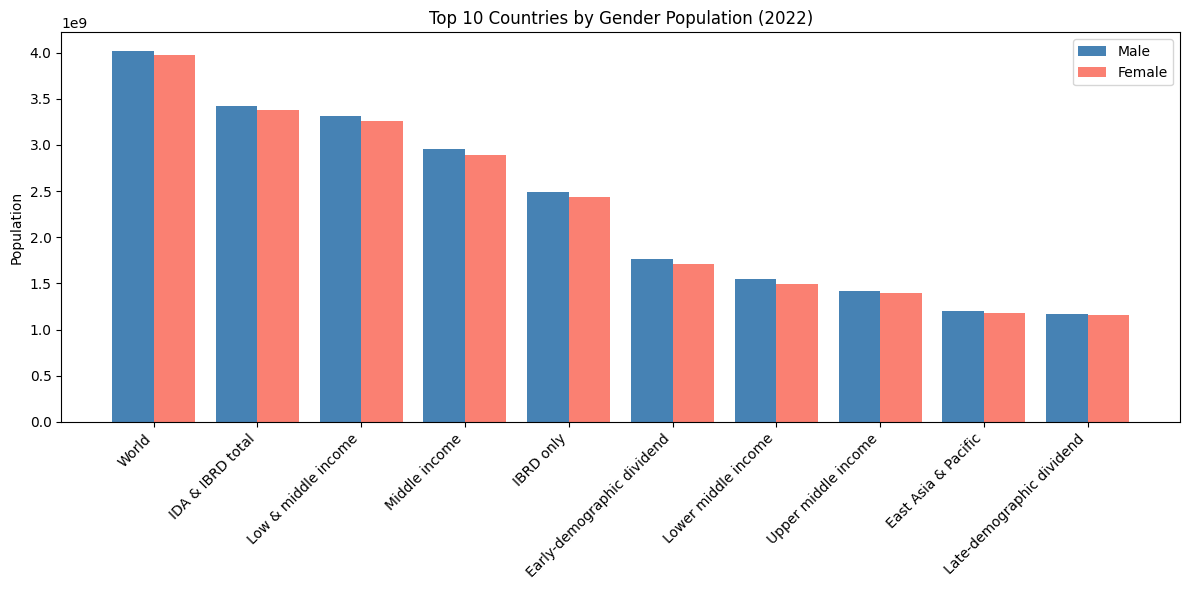

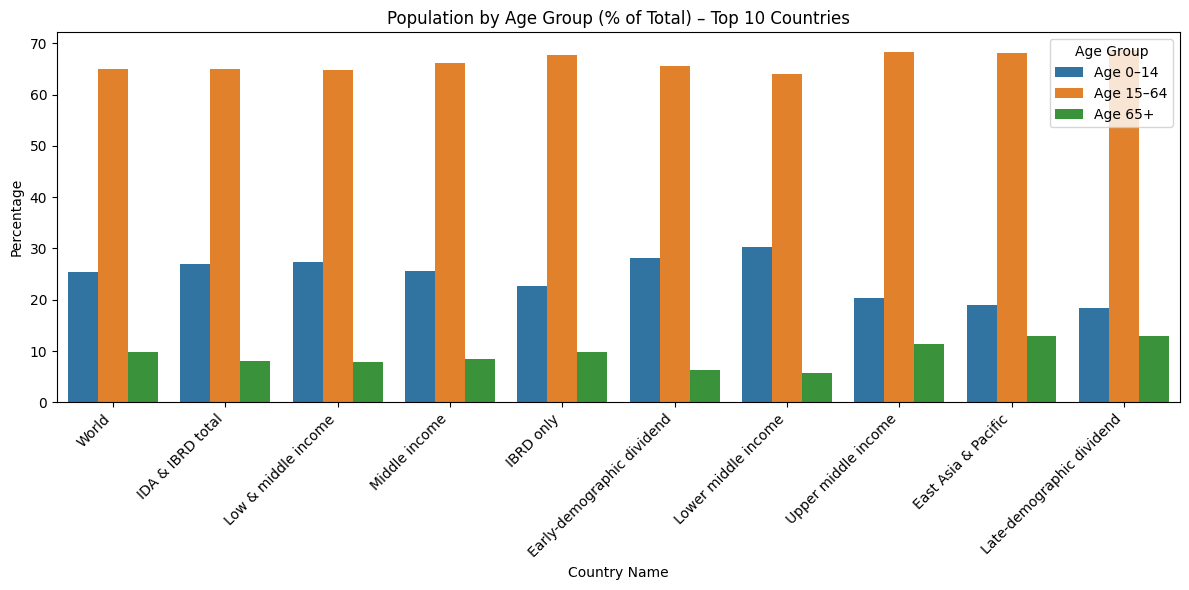

In [7]:

def population_by_gender_and_age():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import zipfile, io, requests

    def fetch_data(indicator_code):
        url = f"https://api.worldbank.org/v2/en/indicator/{indicator_code}?downloadformat=csv"
        r = requests.get(url)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        file_name = [f for f in z.namelist() if f.endswith('.csv') and 'Metadata' not in f][0]
        df = pd.read_csv(z.open(file_name), skiprows=4)
        return df[['Country Name', '2022']].rename(columns={'2022': indicator_code})

    # Population by gender
    df_male = fetch_data('SP.POP.TOTL.MA.IN')  # Male
    df_female = fetch_data('SP.POP.TOTL.FE.IN')  # Female

    # Merge gender data
    df_gender = pd.merge(df_male, df_female, on='Country Name')
    df_gender = df_gender.dropna().sort_values(by='SP.POP.TOTL.MA.IN', ascending=False).head(10)

    # Plot gender bar chart
    plt.figure(figsize=(12, 6))
    bar_width = 0.4
    countries = df_gender['Country Name']
    x = range(len(countries))

    plt.bar(x, df_gender['SP.POP.TOTL.MA.IN'], width=bar_width, label='Male', color='steelblue')
    plt.bar([i + bar_width for i in x], df_gender['SP.POP.TOTL.FE.IN'], width=bar_width, label='Female', color='salmon')
    plt.xticks([i + bar_width / 2 for i in x], countries, rotation=45, ha='right')
    plt.ylabel('Population')
    plt.title('Top 10 Countries by Gender Population (2022)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Population age groups
    df_age_0_14 = fetch_data('SP.POP.0014.TO.ZS')  # % of population age 0–14
    df_age_15_64 = fetch_data('SP.POP.1564.TO.ZS')  # % of population age 15–64
    df_age_65_up = fetch_data('SP.POP.65UP.TO.ZS')  # % of population age 65+

    # Merge age data
    df_age = df_age_0_14.merge(df_age_15_64, on='Country Name') \
                        .merge(df_age_65_up, on='Country Name') \
                        .dropna()

    # Select top 10 countries by total population (same order as gender chart)
    df_age = df_age[df_age['Country Name'].isin(df_gender['Country Name'])]
    df_age = df_age.set_index('Country Name').loc[df_gender['Country Name']].reset_index()

    # Plot age group bar chart
    plt.figure(figsize=(12, 6))
    df_age_plot = df_age.melt(id_vars='Country Name',
                              value_vars=['SP.POP.0014.TO.ZS', 'SP.POP.1564.TO.ZS', 'SP.POP.65UP.TO.ZS'],
                              var_name='Age Group', value_name='Percentage')

    age_labels = {
        'SP.POP.0014.TO.ZS': 'Age 0–14',
        'SP.POP.1564.TO.ZS': 'Age 15–64',
        'SP.POP.65UP.TO.ZS': 'Age 65+'
    }
    df_age_plot['Age Group'] = df_age_plot['Age Group'].map(age_labels)

    sns.barplot(data=df_age_plot, x='Country Name', y='Percentage', hue='Age Group')
    plt.xticks(rotation=45, ha='right')
    plt.title('Population by Age Group (% of Total) – Top 10 Countries')
    plt.tight_layout()
    plt.show()

population_by_gender_and_age()
